In [ ]:
!pip install xgboost catboost imbalanced-learn shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import EditedNearestNeighbours

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, Model



# Interpretability
import shap


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving WineQT.csv to WineQT.csv


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/WineQT.csv")

# Convert to binary classification
df['quality_label'] = (df['quality'] > 7).astype(int)

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
input_dim = X_train_scaled.shape[1]
latent_dim = 6

# Encoder
inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(16, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = Model(inputs, z)

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
h_decoded = layers.Dense(16, activation='relu')(latent_inputs)
outputs = layers.Dense(input_dim)(h_decoded)
decoder = Model(latent_inputs, outputs)

# VAE Model
vae_outputs = decoder(encoder(inputs))
vae = Model(inputs, vae_outputs)

vae.compile(optimizer='adam', loss='mse')

vae.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Encode features
X_train_vae = encoder.predict(X_train_scaled)
X_test_vae = encoder.predict(X_test_scaled)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
X_reconstructed = vae.predict(X_train_scaled)
SSR = np.sum((X_train_scaled - X_reconstructed) ** 2)
print("SSR value:", SSR)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
SSR value: 2303.829321625796


In [ ]:
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train_vae, y_train)


In [ ]:
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train_vae, y_train)


In [ ]:
enn = EditedNearestNeighbours()
X_enn, y_enn = enn.fit_resample(X_train_vae, y_train)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_smt, y_smt)   # <<< THIS LINE TRAINS THE MODEL


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_pred = rf.predict(X_test_vae)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted')
rf_rec  = recall_score(y_test, rf_pred, average='weighted')
rf_f1   = f1_score(y_test, rf_pred, average='weighted')

print("Random Forest")
print("Accuracy :", rf_acc)
print("Precision:", rf_prec)
print("Recall   :", rf_rec)
print("F1-score :", rf_f1)


Random Forest
Accuracy : 0.9563318777292577
Precision: 0.9793833531824799
Recall   : 0.9563318777292577
F1-score : 0.9669551765327903


In [ ]:

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_smt, y_smt)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test_vae)

xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred, average='weighted')
xgb_rec  = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1   = f1_score(y_test, xgb_pred, average='weighted')

print("XGBoost")
print("Accuracy :", xgb_acc)
print("Precision:", xgb_prec)
print("Recall   :", xgb_rec)
print("F1-score :", xgb_f1)
print()



XGBoost
Accuracy : 0.9519650655021834
Precision: 0.979196825586728
Recall   : 0.9519650655021834
F1-score : 0.9645197450113794



In [ ]:
cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

cat.fit(X_smt, y_smt)



In [ ]:
cat_pred = cat.predict(X_test_vae)

cat_acc  = accuracy_score(y_test, cat_pred)
cat_prec = precision_score(y_test, cat_pred, average='weighted')
cat_rec  = recall_score(y_test, cat_pred, average='weighted')
cat_f1   = f1_score(y_test, cat_pred, average='weighted')

print("CatBoost")
print("Accuracy :", cat_acc)
print("Precision:", cat_prec)
print("Recall   :", cat_rec)
print("F1-score :", cat_f1)
print()


CatBoost
Accuracy : 0.9475982532751092
Precision: 0.9790363876738623
Recall   : 0.9475982532751092
F1-score : 0.9620980931024599



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier


In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_smt, y_smt)




GradientBoostingClassifier(n_estimators=200, random_state=42)

In [ ]:
gb_pred = gb.predict(X_test_vae)

gb_acc  = accuracy_score(y_test, gb_pred)
gb_prec = precision_score(y_test, gb_pred, average='weighted')
gb_rec  = recall_score(y_test, gb_pred, average='weighted')
gb_f1   = f1_score(y_test, gb_pred, average='weighted')

print("Gradient Boosting")
print("Accuracy :", gb_acc)
print("Precision:", gb_prec)
print("Recall   :", gb_rec)
print("F1-score :", gb_f1)
print()


Gradient Boosting
Accuracy : 0.9432314410480349
Precision: 0.9788954178656953
Recall   : 0.9432314410480349
F1-score : 0.959685352942916



In [ ]:
print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)
print("CatBoost Accuracy:", cat_acc)


Random Forest Accuracy: 0.9563318777292577
XGBoost Accuracy: 0.9519650655021834
CatBoost Accuracy: 0.9475982532751092


In [ ]:
estimators = [
    ('rf', rf),
    ('xgb', xgb),
    ('cat', cat),
    ('gb', gb)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_smt, y_smt)
stack_pred = stack_model.predict(X_test_vae)

stack_acc  = accuracy_score(y_test, stack_pred)
stack_prec = precision_score(y_test, stack_pred, average='weighted')
stack_rec  = recall_score(y_test, stack_pred, average='weighted')
stack_f1   = f1_score(y_test, stack_pred, average='weighted')

print("Stacking Ensemble (Proposed)")
print("Accuracy :", stack_acc)
print("Precision:", stack_prec)
print("Recall   :", stack_rec)
print("F1-score :", stack_f1)
print()




Stacking Ensemble (Proposed)
Accuracy : 0.9694323144104804
Precision: 0.9802318522725048
Recall   : 0.9694323144104804
F1-score : 0.9744248094585088



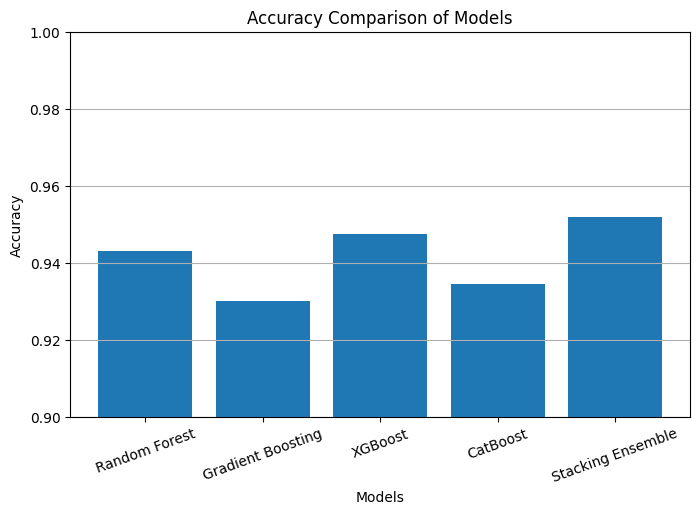

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Random Forest',
    'Gradient Boosting',
    'XGBoost',
    'CatBoost',
    'Stacking Ensemble'
]

accuracy = [
    0.9432,
    0.9301,
    0.9476,
    0.9345,
    0.9520
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models')
plt.ylim(0.90, 1.00)
plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()


Meta-Classifier (Logistic Regression) Weights:
          Base Model  Contribution Weight
0      Random Forest             4.527366
2           CatBoost             4.024202
1            XGBoost             1.122030
3  Gradient Boosting             0.666785


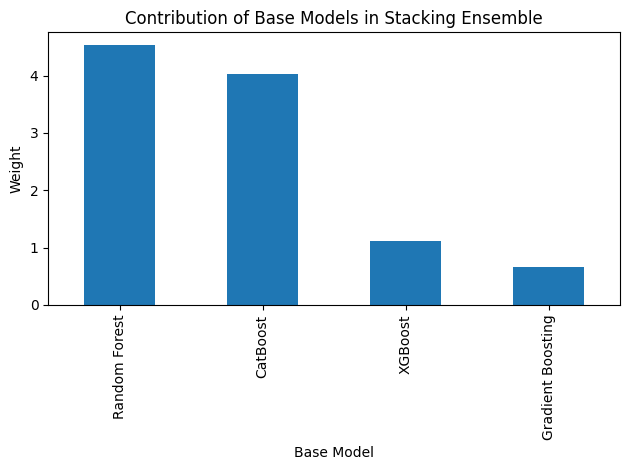

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract Logistic Regression weights
meta_weights = stack_model.final_estimator_.coef_[0]

meta_df = pd.DataFrame({
    'Base Model': ['Random Forest', 'XGBoost', 'CatBoost', 'Gradient Boosting'],
    'Contribution Weight': meta_weights
}).sort_values(by='Contribution Weight', ascending=False)

print("Meta-Classifier (Logistic Regression) Weights:")
print(meta_df)

# Plot contributions
meta_df.plot(
    x='Base Model',
    y='Contribution Weight',
    kind='bar',
    legend=False,
    title='Contribution of Base Models in Stacking Ensemble'
)

plt.ylabel('Weight')
plt.xlabel('Base Model')
plt.tight_layout()
plt.show()
